<a href="https://colab.research.google.com/github/omerbibin/pneumonia-detection-cxr/blob/main/Week02_Data_Acquisition.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Mount Google Drive so that downloaded data persists across Colab sessions.
# Without this, the dataset would have to be re-downloaded every time the runtime resets.

from google.colab import drive          # Colab helper for Drive integration
drive.mount('/content/drive')           # Triggers an OAuth prompt the first time

# Sanity check: confirm the project root from Week 1 is reachable.
import os
PROJECT_ROOT = "/content/drive/MyDrive/PneumoniaDetection"
assert os.path.isdir(PROJECT_ROOT), f"Project root not found at {PROJECT_ROOT}. Re-run Week 1 setup."
print("Drive mounted. Project root verified at:", PROJECT_ROOT)

Mounted at /content/drive
Drive mounted. Project root verified at: /content/drive/MyDrive/PneumoniaDetection


In [ ]:
# The Kaggle Python package ships with a CLI binary used to download datasets.
# Colab usually has it preinstalled, but we pin it explicitly for reproducibility.

!pip install --quiet --upgrade kaggle    # --quiet keeps the notebook output clean
!kaggle --version                        # Print version for the project record

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.4/95.4 kB 6.2 MB/s eta 0:00:00
Kaggle CLI 2.1.0


In [ ]:
%%bash
# Create the .kaggle config directory in the user's home folder.
# -p means "no error if it already exists" — safe to re-run this cell.
mkdir -p ~/.kaggle

# Write the credentials file using a heredoc. This is the CLI-only equivalent
# of the manual "upload kaggle.json" step. Replace the two placeholders below.
cat > ~/.kaggle/kaggle.json << 'EOF'
{"username":"omerfaruk5453","key":"KEY INPUT PRIVATEEOF

# Restrict permissions so only the current user can read the file.
# Kaggle CLI will refuse to run if this file is world-readable.
chmod 600 ~/.kaggle/kaggle.json

# Verify the file exists and has the correct permissions.
ls -la ~/.kaggle/kaggle.json

-rw------- 1 root root 75 May  1 13:56 /root/.kaggle/kaggle.json


In [ ]:
# Centralize all paths in one place so subsequent cells (and weeks) reference them consistently.
import os

PROJECT_ROOT = "/content/drive/MyDrive/PneumoniaDetection"        # From Week 1
DRIVE_RAW    = os.path.join(PROJECT_ROOT, "data", "raw")          # Persistent storage
LOCAL_CACHE  = "/content/kaggle_cache"                            # Fast local scratch
LOCAL_DATA   = "/content/chest_xray"                              # Working copy for training
REPORTS_DIR  = os.path.join(PROJECT_ROOT, "reports")              # For inventory CSV

# Ensure all directories exist before we write to them.
for path in [DRIVE_RAW, LOCAL_CACHE, REPORTS_DIR]:
    os.makedirs(path, exist_ok=True)

# Print a confirmation table so the cell output is self-documenting.
for name, path in [("PROJECT_ROOT", PROJECT_ROOT), ("DRIVE_RAW", DRIVE_RAW),
                   ("LOCAL_CACHE", LOCAL_CACHE), ("LOCAL_DATA", LOCAL_DATA),
                   ("REPORTS_DIR", REPORTS_DIR)]:
    print(f"{name:<14} -> {path}")

PROJECT_ROOT   -> /content/drive/MyDrive/PneumoniaDetection
DRIVE_RAW      -> /content/drive/MyDrive/PneumoniaDetection/data/raw
LOCAL_CACHE    -> /content/kaggle_cache
LOCAL_DATA     -> /content/chest_xray
REPORTS_DIR    -> /content/drive/MyDrive/PneumoniaDetection/reports


In [ ]:
%%bash
# Download the chest-xray-pneumonia dataset from Kaggle into the local cache.
# -d specifies the dataset slug, -p specifies the download directory.
# The zip is ~1.2 GB; download takes 1-3 minutes on a Colab Pro instance.
kaggle datasets download \
    -d paultimothymooney/chest-xray-pneumonia \
    -p /content/kaggle_cache \
    --force      # Overwrite if a stale partial download exists

# Confirm the zip arrived and report its size for the project record.
ls -lh /content/kaggle_cache/*.zip

Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
License(s): other

-rw-r--r-- 1 root root 2.3G Sep 28  2019 /content/kaggle_cache/chest-xray-pneumonia.zip


100%|██████████| 2.29G/2.29G [00:22<00:00, 107MB/s] 


In [ ]:
# Two-stage extraction:
#   (a) unzip locally  -> fast (~30 seconds on Colab SSD)
#   (b) copy to Drive  -> slow (~10-15 minutes for ~6,000 small files), but ONE-TIME
# After this cell, future sessions can skip Cells 5-6 entirely.

import zipfile, shutil, time

zip_path = "/content/kaggle_cache/chest-xray-pneumonia.zip"

# (a) Unzip into LOCAL_DATA. Kaggle's archive contains a top-level "chest_xray/" folder.
print("Unzipping to local SSD...")
t0 = time.time()
with zipfile.ZipFile(zip_path, 'r') as z:
    z.extractall("/content")              # Produces /content/chest_xray/
print(f"  Done in {time.time()-t0:.1f}s")

# (b) Copy to Drive for persistence. We use shutil.copytree with dirs_exist_ok=True
# so the cell is idempotent — re-running won't crash on existing folders.
print("Copying to Drive (this takes 10-15 minutes; do not interrupt)...")
t0 = time.time()
shutil.copytree(
    "/content/chest_xray",
    os.path.join(DRIVE_RAW, "chest_xray"),
    dirs_exist_ok=True
)
print(f"  Done in {time.time()-t0:.1f}s")

Unzipping to local SSD...
  Done in 42.0s
Copying to Drive (this takes 10-15 minutes; do not interrupt)...
  Done in 454.1s


In [ ]:
# Walk the extracted tree and count images per (split, class). This is our
# "ground-truth inventory" — we'll reference these numbers in Weeks 3 and 7.

import pandas as pd
from pathlib import Path

DATA_DIR = Path("/content/chest_xray")    # Use the local copy; faster than Drive

rows = []
for split in ["train", "val", "test"]:
    for cls in ["NORMAL", "PNEUMONIA"]:
        folder = DATA_DIR / split / cls
        # Count .jpeg + .jpg files; case-insensitive via two passes
        n_images = len(list(folder.glob("*.jpeg"))) + len(list(folder.glob("*.jpg")))
        rows.append({"split": split, "class": cls, "count": n_images})

inventory = pd.DataFrame(rows)
print(inventory.to_string(index=False))

# Add totals row for readability
totals = inventory.groupby("split")["count"].sum().reset_index()
totals["class"] = "TOTAL"
print("\nPer-split totals:")
print(totals[["split", "class", "count"]].to_string(index=False))

# Persist the inventory to Drive so the report has a citable artifact.
inventory_path = os.path.join(REPORTS_DIR, "data_inventory.csv")
inventory.to_csv(inventory_path, index=False)
print(f"\nInventory saved to: {inventory_path}")

split     class  count
train    NORMAL   1341
train PNEUMONIA   3875
  val    NORMAL      8
  val PNEUMONIA      8
 test    NORMAL    234
 test PNEUMONIA    390

Per-split totals:
split class  count
 test TOTAL    624
train TOTAL   5216
  val TOTAL     16

Inventory saved to: /content/drive/MyDrive/PneumoniaDetection/reports/data_inventory.csv


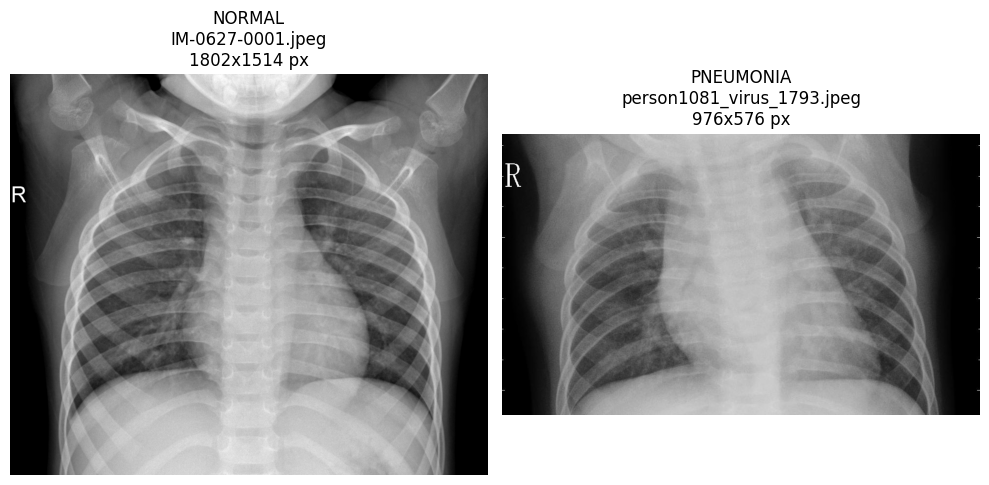

In [ ]:
# Visual spot-check: display one NORMAL and one PNEUMONIA image to confirm
# the data is what we expect (grayscale frontal CXR, not corrupted).

import matplotlib.pyplot as plt
from PIL import Image

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
for ax, cls in zip(axes, ["NORMAL", "PNEUMONIA"]):
    sample = next((DATA_DIR / "train" / cls).glob("*.jpeg"))   # First image found
    img = Image.open(sample)
    ax.imshow(img, cmap="gray")
    ax.set_title(f"{cls}\n{sample.name}\n{img.size[0]}x{img.size[1]} px")
    ax.axis("off")
plt.tight_layout()
plt.show()